# Fake News Detection - Inference Demo
Complete inference pipeline with Ensemble Model and Explainable AI

## Setup & Imports

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../..'))

import torch
from transformers import AutoTokenizer
import numpy as np
from IPython.display import HTML, display

# Import custom modules
from src.model import HybridModel, EnsembleWrapper
from src.features import TextStyleExtractor
from src.rag_utils import RAGSearch
from src.xai_utils import explain_prediction, visualize_importance, plot_top_attributions, get_style_feature_importance
import src.preprocessing as preprocessing

print("✓ Imports successful")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

✓ Imports successful
PyTorch Version: 2.10.0+cu128
CUDA Available: True


## Configuration

In [2]:
# Paths to trained models
PHOBERT_MODEL_PATH = "../../checkpoints/phobert_best.pth"
VISOBERT_MODEL_PATH = "../../checkpoints/visobert_best.pth"
DATA_DIR = "../../Organized"

# Model configuration (must match training)
MAX_LEN = 256  # FIX: Match training MAX_LEN (was 512)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")
print(f"MAX_LEN: {MAX_LEN}")
print(f"PhoBERT Model: {PHOBERT_MODEL_PATH}")
print(f"ViSoBERT Model: {VISOBERT_MODEL_PATH}")

Device: cuda
MAX_LEN: 256
PhoBERT Model: ../../checkpoints/phobert_best.pth
ViSoBERT Model: ../../checkpoints/visobert_best.pth


## Load Ensemble Model

In [3]:
import gc

# Load the ensemble wrapper with both trained models
# EnsembleWrapper loads BOTH tokenizers internally (dual-tokenizer mode)
ensemble = EnsembleWrapper(
    phobert_path=PHOBERT_MODEL_PATH,
    visobert_path=VISOBERT_MODEL_PATH,
    device=DEVICE,
    max_len=MAX_LEN
)

# Convert to FP16 for inference — halves GPU memory (~2GB → ~1GB)
ensemble.model_a.half()
ensemble.model_b.half()
print("[INFO] Models converted to FP16 for inference")

# Free any leftover CPU memory from model loading
gc.collect()
torch.cuda.empty_cache()

# Initialize components for preprocessing
print("\nInitializing components...")
rag_searcher = RAGSearch(database_jsonl_paths=DATA_DIR, cache_path="../../rag_cache")
style_extractor = TextStyleExtractor()

# Tokenizer shortcuts
phobert_tokenizer = ensemble.tokenizer_a
visobert_tokenizer = ensemble.tokenizer_b

print(f"\nGPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB used")
print("Ensemble and components ready")

[INFO] Loading Ensemble Models on cuda...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[INFO] HybridModel initialized with vinai/phobert-base-v2
[INFO] Fusion dimension: 768 (BERT) + 10 (Style) = 778


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: uitnlp/visobert
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[INFO] HybridModel initialized with uitnlp/visobert
[INFO] Fusion dimension: 768 (BERT) + 10 (Style) = 778
[INFO] Ensemble Ready (dual-tokenizer mode).
[INFO] Models converted to FP16 for inference

Initializing components...
----------- Initializing Hybrid RAG -----------


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading cached RAG...
Cache loaded.

GPU memory: 0.59 GB used
Ensemble and components ready


In [4]:
# Usage Example (pseudocode)

# Option A: Using predict_text (recommended — handles tokenization internally)
# label, conf = ensemble.predict_text(text="cleaned text here", style_vector=style_tensor)

# Option B: Using __call__ with pre-tokenized inputs (dual tokenizer)
# label, conf = ensemble(
#     input_ids_a=phobert_tokens['input_ids'],
#     attention_mask_a=phobert_tokens['attention_mask'],
#     input_ids_b=visobert_tokens['input_ids'],
#     attention_mask_b=visobert_tokens['attention_mask'],
#     style_vector=style_tensor
# )

# Label encoding: 0 = FAKE, 1 = REAL
# print(f"Result: {'REAL' if label == 1 else 'FAKE'}")
# print(f"Confidence: {conf:.4f}")
print("Usage examples above (uncomment to run)")

Usage examples above (uncomment to run)


## Prediction Pipeline Function
Create a complete end-to-end prediction function

In [4]:
def predict_news(text: str, show_xai: bool = True):
    """
    Complete prediction pipeline: Raw Text → Prediction → XAI Visualization
    
    Args:
        text: Vietnamese news text to classify
        show_xai: Whether to show explainability visualizations
        
    Returns:
        dict: Prediction results with confidence scores
    """
    print("=" * 80)
    print("PREDICTION PIPELINE")
    print("=" * 80)
    print(f"\nInput Text:\n{text[:200]}...\n")
    
    # Step 1: RAG Retrieval
    print("[1/5] Retrieving evidence...")
    evidence, bm25_score, mean_idf = rag_searcher(text)
    print(f"  Evidence found: {len(evidence)} chars")
    print(f"  BM25 Score: {bm25_score:.4f}")
    
    # Step 2: Feature Extraction
    print("[2/5] Extracting style features...")
    style_vec = style_extractor.get_style_vector(text, mean_idf=mean_idf, bm25_score=bm25_score)
    style_tensor = torch.tensor(style_vec, dtype=torch.float32)
    print(f"  Style vector: {style_vec[:5]}...")
    
    # Step 3: Preprocessing
    print("[3/5] Preprocessing...")
    clean_text_str = preprocessing.clean_text(text)
    clean_evidence = preprocessing.clean_text(evidence) if evidence else None
    
    # Step 4: Ensemble Prediction
    # FIX: Pass text and evidence separately → sentence-pair tokenization
    # [CLS] text [SEP] evidence [SEP] with evidence capped at 150 tokens.
    # Previously combined_text concatenated them as a single string, causing
    # evidence (~11K chars of real KB text) to overwhelm the short input (~300 chars).
    print("[4/5] Running ensemble prediction...")
    label, confidence = ensemble.predict_text(
        clean_text_str, style_tensor, evidence=clean_evidence
    )
    
    # Get individual model predictions
    individual_preds = ensemble.get_individual_predictions(
        clean_text_str, style_tensor, evidence=clean_evidence
    )
    
    # FIX: Label encoding is FAKE=0, REAL=1
    result_text = "REAL" if label == 1 else "FAKE"
    print(f"\n{'='*80}")
    print(f"PREDICTION: {result_text}")
    print(f"Confidence: {confidence:.4f} ({confidence*100:.2f}%)")
    print(f"{'='*80}")
    
    phobert_label = "REAL" if individual_preds['phobert']['prediction'] == 1 else "FAKE"
    visobert_label = "REAL" if individual_preds['visobert']['prediction'] == 1 else "FAKE"
    print(f"\nIndividual Model Predictions:")
    print(f"  PhoBERT:  {phobert_label} (conf: {individual_preds['phobert']['confidence']:.4f})")
    print(f"  ViSoBERT: {visobert_label} (conf: {individual_preds['visobert']['confidence']:.4f})")
    
    # Step 5: Explainability (XAI)
    if show_xai:
        print(f"\n[5/5] Generating explanations...")
        
        # Use PhoBERT model for XAI — tokenize as sentence pair with evidence cap
        model_for_xai = ensemble.model_a
        evidence_limit = 150
        xai_evidence = clean_evidence
        if xai_evidence:
            evid_ids = phobert_tokenizer.encode(xai_evidence, add_special_tokens=False)
            if len(evid_ids) > evidence_limit:
                evid_ids = evid_ids[:evidence_limit]
                xai_evidence = phobert_tokenizer.decode(evid_ids, skip_special_tokens=True)
        
        enc_xai = phobert_tokenizer(
            clean_text_str,
            text_pair=xai_evidence,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        xai_ids = enc_xai['input_ids'].to(DEVICE)
        xai_mask = enc_xai['attention_mask'].to(DEVICE)
        
        importances = explain_prediction(
            model_for_xai, 
            xai_ids, 
            xai_mask, 
            style_tensor.unsqueeze(0).to(DEVICE) if style_tensor.dim() == 1 else style_tensor.to(DEVICE),
            target_class=label
        )
        
        # Visualize token importance
        print("\nToken Importance Visualization:")
        html_viz = visualize_importance(phobert_tokenizer, xai_ids, importances, top_k=20)
        display(HTML(html_viz))
        
        # Plot top attributions
        plot_top_attributions(phobert_tokenizer, xai_ids, importances, top_k=15)
        
        # Style feature importance
        style_importance = get_style_feature_importance(
            model_for_xai, xai_ids, xai_mask, style_tensor
        )
        print(f"\nStyle Feature Importance:")
        for feat, score in sorted(style_importance.items(), key=lambda x: x[1], reverse=True)[:5]:
            print(f"  {feat}: {score:.4f}")
    
    return {
        'prediction': result_text,
        'label': label,
        'confidence': confidence,
        'phobert': individual_preds['phobert'],
        'visobert': individual_preds['visobert'],
        'style_vector': style_vec,
        'evidence': evidence
    }

print("✓ Prediction pipeline ready")

✓ Prediction pipeline ready


## Test Cases
Run predictions on sample news articles

Ground truth: FAKE (label=0)
Text preview: GHẾ TỔNG BÍ THƯ 100% TUYỆT ĐỐI, ĐỐ AI DÁM KHÔNG BỎ PHIẾU CHO TÔ LÂM Sáng 23/1/2026, Tô Lâm được Trung ương “thống nhất cao” bầu giữ chức Tổng Bí thư với số phiếu tuyệt đối 100%. Nghĩa là không sót một lá phiếu nào. Và dĩ nhiên, trong con số tuyệt đối ấy, có cả lá phiếu của chính ông Tô Lâm dành cho ...

PREDICTION PIPELINE

Input Text:
GHẾ TỔNG BÍ THƯ 100% TUYỆT ĐỐI, ĐỐ AI DÁM KHÔNG BỎ PHIẾU CHO TÔ LÂM Sáng 23/1/2026, Tô Lâm được Trung ương “thống nhất cao” bầu giữ chức Tổng Bí thư với số phiếu tuyệt đối 100%. Nghĩa là không sót một...

[1/5] Retrieving evidence...
  Evidence found: 49527 chars
  BM25 Score: 1.0000
[2/5] Extracting style features...
  Style vector: [0.0816326530612245, 0.02173913043478261, 0.8040157136158815, 0.919845148555843, 0.23401594033537082]...
[3/5] Preprocessing...
[4/5] Running ensemble prediction...


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.



PREDICTION: FAKE
Confidence: 0.9863 (98.63%)

Individual Model Predictions:
  PhoBERT:  FAKE (conf: 0.9908)
  ViSoBERT: FAKE (conf: 0.9819)

[5/5] Generating explanations...

Token Importance Visualization:



Style Feature Importance:
  lexical_diversity: 0.0091
  punct_ratio: 0.0044
  mean_idf: 0.0041
  sentiment_score: 0.0036
  caps_ratio: 0.0032


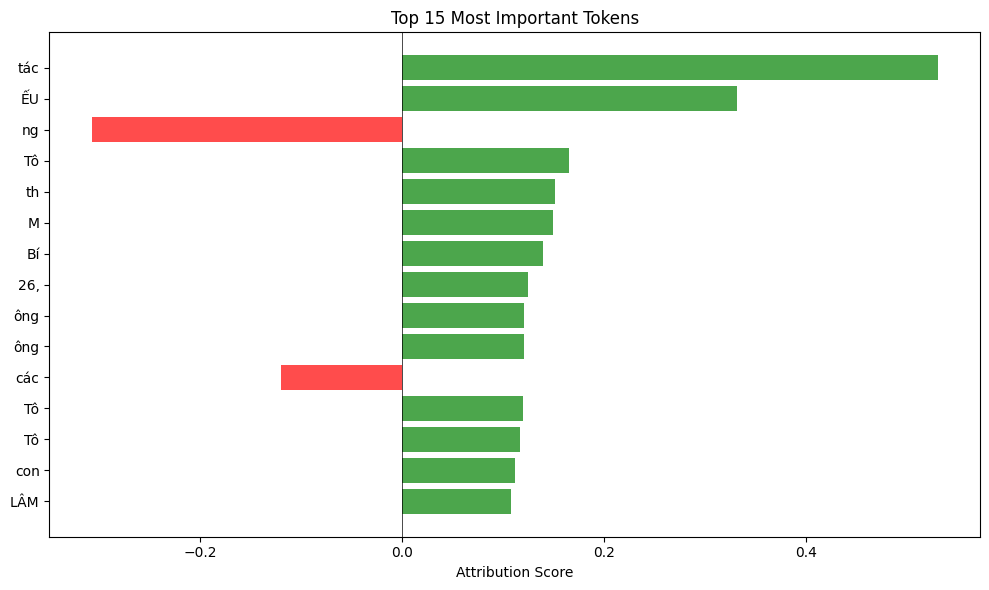

In [11]:
# Example 1: Real FAKE sample from dataset
import json

with open("../../Organized/FAKE_Social.jsonl", 'r', encoding='utf-8') as f:
    fake_sample = json.loads(f.readlines()[5])  # 6th sample

fake_news_example = fake_sample["text"]
print(f"Ground truth: FAKE (label={fake_sample['label']})")
print(f"Text preview: {fake_news_example[:300]}...\n")

result1 = predict_news(fake_news_example, show_xai=True)

Ground truth: REAL (label=1)
Text preview: Ngày 3-2, Ethiopian Airlines cho biết hành khách xuất phát từ sân bay Changi (Singapore) có thể tham gia chương trình ưu đãi áp dụng cho vé đặt từ ngày 2-2 đến 26-2, thời gian khởi hành từ 2-2 đến 14-6. Vé được bán qua website, ứng dụng di động của hãng và các đại lý ủy quyền. Bên cạnh chương trình ...

PREDICTION PIPELINE

Input Text:
Ngày 3-2, Ethiopian Airlines cho biết hành khách xuất phát từ sân bay Changi (Singapore) có thể tham gia chương trình ưu đãi áp dụng cho vé đặt từ ngày 2-2 đến 26-2, thời gian khởi hành từ 2-2 đến 14-...

[1/5] Retrieving evidence...


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


  Evidence found: 16477 chars
  BM25 Score: 1.0000
[2/5] Extracting style features...
  Style vector: [0.0, 0.0, 0.8029509301217654, 0.9362780579454046, 0.2660964511563887]...
[3/5] Preprocessing...
[4/5] Running ensemble prediction...


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.



PREDICTION: REAL
Confidence: 0.9930 (99.30%)

Individual Model Predictions:
  PhoBERT:  REAL (conf: 0.9938)
  ViSoBERT: REAL (conf: 0.9922)

[5/5] Generating explanations...

Token Importance Visualization:



Style Feature Importance:
  max_bm25_score: 0.0129
  subjectivity_score: 0.0072
  word_count_normalized: 0.0064
  lexical_diversity: 0.0051
  typo_density: 0.0047


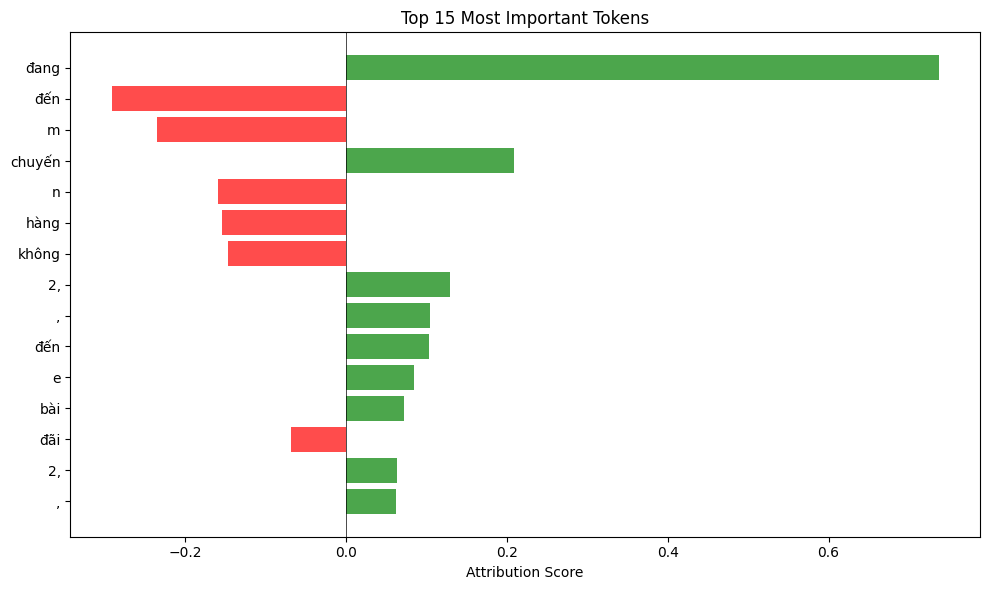

In [12]:
# Example 2: Real REAL sample from dataset
with open("../../Organized/REAL_Article.jsonl", 'r', encoding='utf-8') as f:
    real_sample = json.loads(f.readlines()[10])  # 11th sample

real_news_example = real_sample["text"]
print(f"Ground truth: REAL (label={real_sample['label']})")
print(f"Text preview: {real_news_example[:300]}...\n")

result2 = predict_news(real_news_example, show_xai=True)

## Batch Testing & Performance Analysis
Load test samples and analyze model performance

In [13]:
# Batch testing function
def batch_test(file_path: str, num_samples: int = 10):
    """Test on multiple samples from a JSONL file"""
    import json
    
    results = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= num_samples:
                break
            data = json.loads(line)
            text = data.get('text', '')
            true_label = data.get('label', -1)
            
            print(f"\n{'='*80}")
            print(f"Sample {i+1}/{num_samples}")
            # FIX: Label encoding is FAKE=0, REAL=1
            print(f"True Label: {'REAL' if true_label == 1 else 'FAKE'}")
            
            result = predict_news(text, show_xai=False)
            result['true_label'] = true_label
            results.append(result)
            
            is_correct = (result['label'] == true_label)
            print(f"Prediction: {result['prediction']} ({'✓ CORRECT' if is_correct else '✗ INCORRECT'})")
    
    # Calculate accuracy
    correct = sum(1 for r in results if r['label'] == r['true_label'])
    accuracy = correct / len(results)
    print(f"\n{'='*80}")
    print(f"BATCH TEST RESULTS")
    print(f"{'='*80}")
    print(f"Total Samples: {len(results)}")
    print(f"Correct: {correct}")
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    return results

# Example: Test on fake news samples
# results = batch_test(os.path.join(DATA_DIR, 'FAKE_Article.jsonl'), num_samples=5)
print("✓ Batch testing function ready")

✓ Batch testing function ready
